In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import copy
import time
import plotly.graph_objects as go

In [74]:

def sigmoid(x):
    return 1/(1+np.exp(-x))

def min_max_vals(x_list, y_list):
    x = np.array(x_list, dtype=np.float32).reshape(-1, 1)
    y = np.array(y_list, dtype=np.float32).reshape(-1, 1)
    return x.min(), x.max(), y.min(), y.max()

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def grad_sigmoid(x):
    return sigmoid(x) * (1 -sigmoid(x))

def tanh(x):
    return np.tanh(x)

def grad_tanh(x):
    return 1 - np.tanh(x)**2

def relu(z):
    return np.maximum(0, z)

def grad_relu(z):
    return (z > 0).astype(float)


def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))


def parse_label(val):
    val = val.strip().upper()
    if val in ('TRUE', '1'):
        return 1.0
    elif val in ('FALSE', '0'):
        return 0.0
    else:
        return int(float(val))


def one_hot(y, num_classes=3):
    y = y.flatten().astype(int)
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

def f_measure(y_true, y_pred):
    if y_true.ndim == 2:
        y_true = np.argmax(y_true, axis=1)
    if y_pred.ndim == 2:
        y_pred = np.argmax(y_pred, axis=1)

    classes = np.unique(y_true)
    f1_per_class = []

    for c in classes:
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        if (precision + recall) > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0.0

        f1_per_class.append(f1)

    return np.mean(f1_per_class)  # macro average



In [25]:
def data_to_matrix(data, test_data):
    x_list, y_list = [], []
    for i, row in enumerate(data):
        if i > 0:
            if len(row) == 4:
                _, x1, x2, y = row      # index + dwie cechy + etykieta
            elif len(row) == 3:
                x1, x2, y = row         # dwie cechy + etykieta
            else:
                raise ValueError(f"Nieoczekiwany format: {row}")
            x_list.append([float(x1), float(x2)])
            y_list.append(parse_label(y))

    test_x_list, test_y_list = [], []
    for i, row in enumerate(test_data):
        if i > 0:
            if len(row) == 4:
                _, x1, x2, y = row
            elif len(row) == 3:
                x1, x2, y = row
            else:
                raise ValueError(f"Nieoczekiwany format: {row}")
            test_x_list.append([float(x1), float(x2)])
            test_y_list.append(parse_label(y))

    return (
        np.array(x_list),                # shape (N, 2)
        np.array(test_x_list),           # shape (M, 2)
        np.array(y_list),                # shape (N,)
        np.array(test_y_list)            # shape (M,)
    )

In [26]:
def load_data(filename):
    with open(f'mio1/classification/{filename}-training.csv') as f_train:
        with open(f'mio1/classification/{filename}-test.csv') as f_test:
            data = list(csv.reader(f_train))
            test_data = list(csv.reader(f_test))
    return data_to_matrix(data, test_data)

In [100]:
class MLP:
    def __init__(self, layer_num, act_func, grad_act_func, w=None, biases_w=None, x_min=None, x_max=None, y_min=None, y_max=None, use_softmax = False):
        self.layer_num = layer_num
        self.act_func = act_func
        self.grad_act_func = grad_act_func
        self.use_softmax = use_softmax
        self.weight_history = []
        
        self.loss_values = []



        if w is None:
            self.w = [np.random.uniform(-1, 1, (layer_num[i], layer_num[i+1])) for i in range(len(layer_num)-1)]
        else:
            self.w = w

        if biases_w is None:
            self.biases_w = [np.random.uniform(-1, 1, (1, layer_num[i+1])) for i in range(len(layer_num)-1)]
        else:
            self.biases_w = biases_w

        self.v_w = [np.zeros_like(w) for w in self.w]
        self.v_biases_w = [np.zeros_like(b) for b in self.biases_w]

        self.s_w = [np.zeros_like(w) for w in self.w]
        self.s_biases_w = [np.zeros_like(b) for b in self.biases_w]
        
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max

    def calc(self, x_denorm): # działa jak forward ale nie wymaga normalizacji przed uruchomieniem
        x_denorm = np.array(x_denorm, dtype=np.float32)
        temp = (x_denorm - self.x_min) / (self.x_max - self.x_min)
        if temp.ndim == 1:
            temp = temp.reshape(1, -1)
            
        self.pre_activation_vals = []
        self.activations = [temp]
        
        for layer_id in range(len(self.layer_num) - 1):
            z = self.activations[-1] @ self.w[layer_id] + self.biases_w[layer_id]
            self.pre_activation_vals.append(z)

            if layer_id < len(self.layer_num) - 2:
                a = self.act_func(z)
            else:
                a = z
            self.activations.append(a)
            
        return self.activations[-1] * (self.y_max - self.y_min) + self.y_min

    def forward(self, x):
        temp = np.array(x, dtype=np.float32)
        if temp.ndim == 1:
            temp = temp.reshape(1, -1)
            
        self.pre_activation_vals = []
        self.activations = [temp]
        
        for layer_id in range(len(self.layer_num) - 1):
            z = self.activations[-1] @ self.w[layer_id] + self.biases_w[layer_id]
            self.pre_activation_vals.append(z)
    
            is_last = (layer_id == len(self.layer_num) - 2)
    
            if is_last and self.use_softmax:
                a = softmax(z)
            elif not is_last:
                a = self.act_func(z)
            else:
                a = z
                
            self.activations.append(a)
            
        return self.activations[-1]

    def backward(self, y_true):
        batch_size = y_true.shape[0]
        length = len(self.layer_num) - 1
        y_pred = self.activations[-1]
        
        grad_w = [None] * length
        grad_biases_w = [None] * length
        
        delta = (y_pred - y_true)
    
        for layer_id in reversed(range(length)):
            a_prev = self.activations[layer_id]
            
            grad_w[layer_id] = (a_prev.T @ delta) / batch_size
            grad_biases_w[layer_id] = np.sum(delta, axis=0, keepdims=True) / batch_size
    
            if layer_id > 0:
                delta = (delta @ self.w[layer_id].T) * self.grad_act_func(
                    self.pre_activation_vals[layer_id - 1]
                )
                
        return grad_w, grad_biases_w

    def update_weights(self, grad_w, grad_biases_w, update_method, lr=0.01, beta=0.9):

        if update_method == 'Momentum':
            for i in range(len(self.w)):
                self.v_w[i] = beta * self.v_w[i] + (1 -  beta) * grad_w[i]
                self.v_biases_w[i] = beta * self.v_biases_w[i] + (1 - beta) * grad_biases_w[i]
                
                self.w[i] -= lr * self.v_w[i]
                self.biases_w[i] -= lr * self.v_biases_w[i]

        elif update_method == 'RMSProp':
            for i in range(len(self.w)):
                self.s_w[i] = beta * self.s_w[i] + (1 - beta) * (grad_w[i] ** 2)
                self.s_biases_w[i] = beta * self.s_biases_w[i] + (1 - beta) * (grad_biases_w[i] ** 2)
            
                self.w[i] -= lr * grad_w[i] / (np.sqrt(self.s_w[i]) + 1e-8)
                self.biases_w[i] -= lr * grad_biases_w[i] / (np.sqrt(self.s_biases_w[i]) + 1e-8)

        else:
            for i in range(len(self.w)):
                self.w[i] -= lr * grad_w[i]
                self.biases_w[i] -= lr * grad_biases_w[i]
            

    def train(self, X, Y, epochs=10000, lr=0.01, batch_size=1,
          update_method=None, beta=0.9, record_loss_every=100, print_every = 1000, verbose=False, gradient_clipping=False):
    
        X = np.array(X)
        Y = np.array(Y)

        if self.use_softmax and Y.ndim == 1:
            Y = one_hot(Y, num_classes=self.layer_num[-1])
        elif self.use_softmax and Y.shape[1] == 1:
            Y = one_hot(Y.flatten(), num_classes=self.layer_num[-1])
    
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
    
        self.x_min, self.x_max = X.min(axis=0), X.max(axis=0)
        if self.use_softmax:
            Y_norm = Y                          # one-hot nie normalizujemy
        else:
            self.y_min, self.y_max = Y.min(axis=0), Y.max(axis=0)
            Y_norm = (Y - self.y_min) / (self.y_max - self.y_min + 1e-8)
    
        X_norm = (X - self.x_min) / (self.x_max - self.x_min + 1e-8)
    
        for epoch in range(epochs):
            indices = np.random.permutation(len(X_norm))
            X_shuffled = X_norm[indices]
            Y_shuffled = Y_norm[indices]
    
            for i in range(0, len(X_norm), batch_size):
                x_batch = X_shuffled[i:i+batch_size]
                y_batch = Y_shuffled[i:i+batch_size]
    
                self.forward(x_batch)
                grad_w, grad_biases_w = self.backward(y_batch)
    
                if gradient_clipping:
                    for i in range(len(grad_w)):
                        grad_w[i] = np.clip(grad_w[i], -5, 5)
                        grad_biases_w[i] = np.clip(grad_biases_w[i], -5, 5)
    
                self.update_weights(grad_w, grad_biases_w, update_method, lr, beta)
    
            if epoch % record_loss_every == 0 or epoch == epochs - 1:
                y_pred_all = self.forward(X_norm)
                if self.use_softmax:
                    loss = cross_entropy(Y, y_pred_all)
                else:
                    loss = np.mean((Y - y_pred_all) ** 2)
                self.loss_values.append(loss)

            if epoch % print_every == 0 or epoch == epochs - 1:
    
                if verbose and not self.use_softmax:
                    print(f'Trenowanie: epoka {epoch} na {epochs} | MSE: {loss:.6f}')
                elif verbose:
                    print(f'Trenowanie: epoka {epoch} na {epochs} | Loss: {loss:.6f}')

        if self.use_softmax:
            y_pred_final = self.forward(X_norm)
            y_pred_cls = np.argmax(y_pred_final, axis=1)
            y_true_cls = np.argmax(Y, axis=1)
        
            plt.figure(figsize=(8, 5))
            plt.scatter(X[:, 0], X[:, 1], c=y_pred_cls, cmap='viridis', alpha=0.6)
            plt.title(f'Predykcja klas | Loss: {self.loss_values[-1]:.6f}')
            plt.xlabel('x1')
            plt.ylabel('x2')
            plt.colorbar(label='Klasa')
            plt.tight_layout()
            plt.show()
        else:
            y_pred_final = self.forward(X)
            sort_idx = np.argsort(X.flatten())
            x_sorted = X.flatten()[sort_idx]
            y_sorted = y_pred_final.flatten()[sort_idx]
        
            plt.figure(figsize=(8, 5))
            plt.scatter(X.flatten(), Y.flatten(), label='Dane', alpha=0.6)
            plt.plot(x_sorted, y_sorted, color='red', linewidth=2, label='Model (ostatnia epoka)')
            plt.title(f'Uczenie MLP | Loss: {self.loss_values[-1]:.6f}')
            plt.xlabel('X')
            plt.ylabel('Y')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        print('========================')
        print('Wagi:')
        print(self.w)
        print('Bias:')
        print(self.biases_w)

            


    def plot_weight_evolution(self, layer_id=0):
        history = []
    
        for epoch_w in self.weight_history:
            history.append(epoch_w[layer_id].flatten())
    
        history = np.array(history)
    
        plt.figure(figsize=(8,5))
    
        for i in range(history.shape[1]):
            plt.plot(history[:, i], alpha=0.5)
    
        plt.title(f"Zmiana wag w czasie (warstwa {layer_id})")
        plt.xlabel("Epoka")
        plt.ylabel("Wartość wagi")
        plt.grid(True)
        plt.show()

    def plot_weight_norms(self):

        norms = []
    
        for epoch_w in self.weight_history:
            norms.append([np.linalg.norm(w) for w in epoch_w])
    
        norms = np.array(norms)
    
        plt.figure(figsize=(8,5))
    
        for i in range(norms.shape[1]):
            plt.plot(norms[:, i], label=f"Warstwa {i}")
    
        plt.title("Norma wag w czasie")
        plt.xlabel("Epoka")
        plt.ylabel("||W||")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    def plot_loss(self, smooth=0, log_scale=True):

        if len(self.loss_values) == 0:
            print("Brak danych o stracie")
            return
    
        loss = np.array(self.loss_values)
        x = np.arange(len(loss))
    
        plt.figure(figsize=(8, 5))
    
        plt.plot(x, loss, alpha=0.4, label="Loss (surowe)")
    
        if smooth > 1:
            kernel = np.ones(smooth) / smooth
            loss_smooth = np.convolve(loss, kernel, mode='valid')
            plt.plot(np.arange(len(loss_smooth)), loss_smooth,
                     linewidth=2, label=f"Loss (średnia {smooth})")
    
        min_idx = np.argmin(loss)
        plt.scatter(min_idx, loss[min_idx], label=f"Min: {loss[min_idx]:.4f}")
    
        plt.title("Loss w trakcie treningu")
        plt.xlabel("Epoka (co zapis)")
        plt.ylabel("Loss")
    
        if log_scale:
            plt.yscale('log')
    
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    def test_evaluation_regression(self, x_test, y_test):
        y_pred = self.calc(x_test)
        plt.figure(figsize=(8,5))
        plt.scatter(x_test, y_test, color='blue', label='Prawdziwe y')
        plt.scatter(x_test, y_pred, color='red', label='Predykcja y_pred', alpha=0.7)
        plt.xlabel('x_test')
        plt.ylabel('y')
        plt.title('Porównanie y_test i y_pred')
        plt.legend()
        plt.show()
        loss = mse(y_test, y_pred)
        print(f"MSE dla modelu: {loss:.6f}")

    def test_evaluation_classification(self, x_test, y_test):
        if y_test.ndim == 1 or y_test.shape[1] == 1:
            y_true_cls = y_test.flatten().astype(int)
        else:
            y_true_cls = np.argmax(y_test, axis=1)
    
        x_test_norm = (x_test - self.x_min) / (self.x_max - self.x_min + 1e-8)
        y_pred = self.forward(x_test_norm)
        y_pred_cls = np.argmax(y_pred, axis=1)
    
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
        axes[0].scatter(x_test[:, 0], x_test[:, 1], c=y_true_cls, cmap='viridis', alpha=0.7)
        axes[0].set_title('Prawdziwe klasy')
        axes[0].set_xlabel('x1')
        axes[0].set_ylabel('x2')
    
        axes[1].scatter(x_test[:, 0], x_test[:, 1], c=y_pred_cls, cmap='viridis', alpha=0.7)
        axes[1].set_title('Predykcja klas')
        axes[1].set_xlabel('x1')
        axes[1].set_ylabel('x2')
    
        plt.tight_layout()
        plt.show()
    
        fm = f_measure(y_true_cls, y_pred_cls)
        acc = np.mean(y_true_cls == y_pred_cls)
        print(f"F-measure (macro): {fm:.4f}")
        print(f"Accuracy:          {acc:.4f}")

In [69]:
# easy

In [101]:
x_train, x_test, y_train, y_test = load_data('easy')

In [102]:
model_easy = MLP(
    layer_num    = [2, 16, 8, 2],
    act_func     = relu,
    grad_act_func= grad_relu,
    use_softmax  = True
)

Trenowanie: epoka 0 na 10000 | Loss: 0.531807
Trenowanie: epoka 1000 na 10000 | Loss: 0.014249
Trenowanie: epoka 2000 na 10000 | Loss: 0.010114
Trenowanie: epoka 3000 na 10000 | Loss: 0.005937
Trenowanie: epoka 4000 na 10000 | Loss: 0.005388
Trenowanie: epoka 5000 na 10000 | Loss: 0.004033
Trenowanie: epoka 6000 na 10000 | Loss: 0.003770
Trenowanie: epoka 7000 na 10000 | Loss: 0.002711
Trenowanie: epoka 8000 na 10000 | Loss: 0.004947
Trenowanie: epoka 9000 na 10000 | Loss: 0.003550
Trenowanie: epoka 9999 na 10000 | Loss: 0.003184


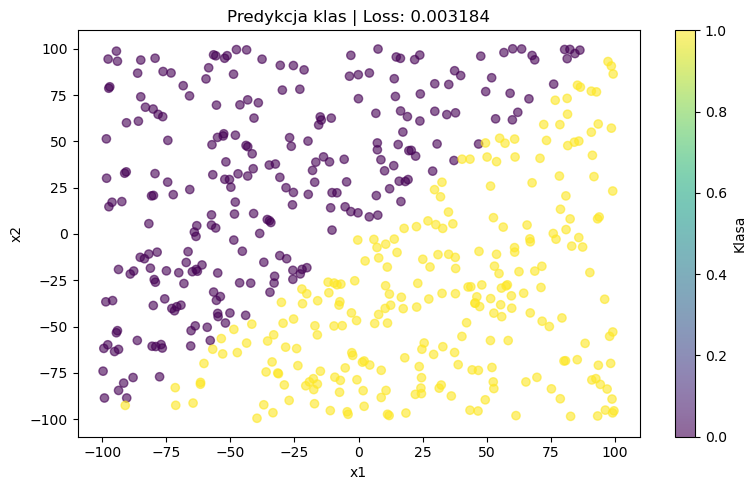

Wagi:
[array([[-1.80266214, -0.5678989 ,  1.08877675, -0.75334635,  0.20632332,
         0.43662263, -3.00646879, -0.53916254,  0.27094496, -0.07925289,
        -0.85609045,  0.42682129,  1.6222628 ,  2.03131066, -2.7338243 ,
         3.33865654],
       [ 1.50686607, -0.90124839, -1.8598123 ,  0.40947565, -0.41467247,
        -0.69011072,  3.97277887, -0.71211495,  0.59424699, -1.22159153,
         0.61226962, -0.81377417, -1.99462244, -0.46750114,  2.96350021,
        -1.84816378]]), array([[ 0.76892993, -0.70796368,  1.78048011,  0.01896047, -1.06804096,
        -0.26098373, -0.39387904, -0.28522481],
       [-0.66629045,  0.30953213,  0.6472816 , -0.41456508, -0.51387594,
         0.62160379, -0.4625168 ,  0.56883188],
       [-0.4027469 ,  0.77239779, -0.36029621,  0.15921667,  1.94039284,
        -0.62257683,  0.71361053,  0.35221999],
       [-0.48491649,  0.96373628, -0.44076163, -0.84297916, -0.33946889,
         0.98798888,  0.07738488,  0.67398533],
       [-0.27046652, -0.9

In [103]:
# train(self, X, Y, epochs=10000, lr=0.01, batch_size=1,
#           update_method=None, beta=0.9, record_every=100, verbose=False, gradient_clipping=False):
model_easy.train(x_train, y_train, epochs=10000, lr=0.01, batch_size=16, update_method="Momentum", verbose = True, record_loss_every = 10, print_every = 1000)

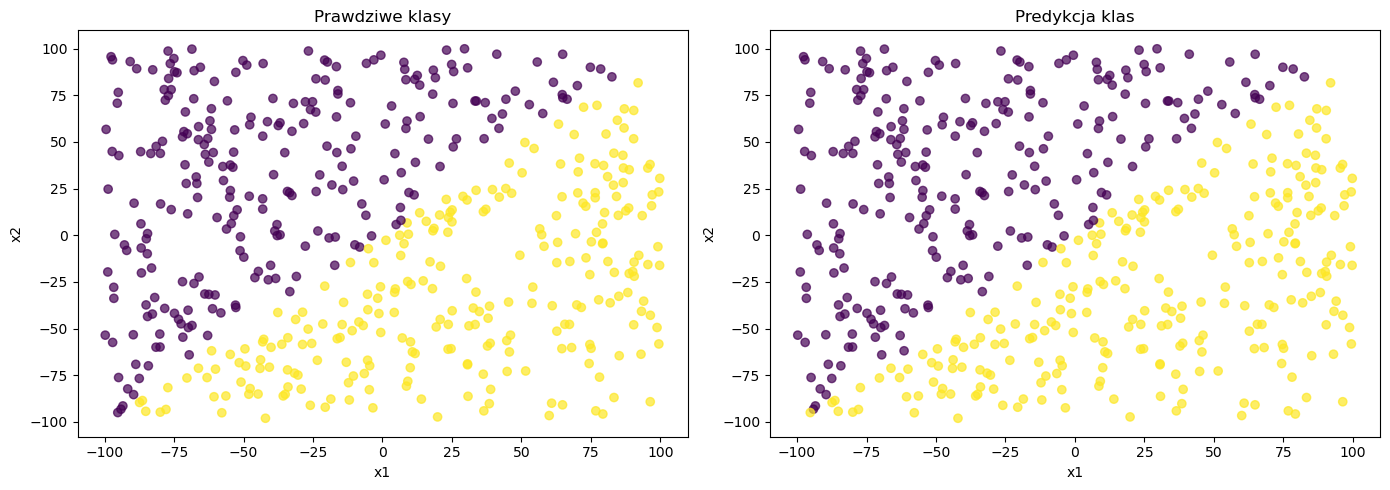

F-measure (macro): 0.9960
Accuracy:          0.9960


In [104]:
model_easy.test_evaluation_classification(x_test, y_test)

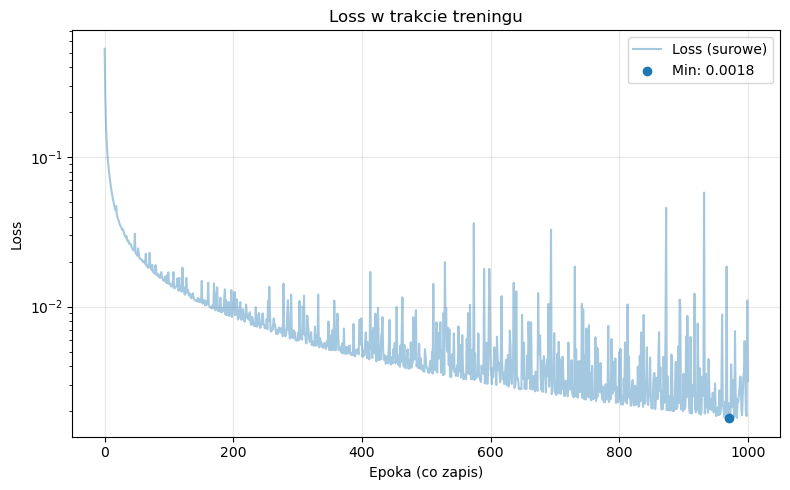

In [105]:
model_easy.plot_loss()

In [ ]:
# xor3

In [106]:
x_train, x_test, y_train, y_test = load_data('xor3')

In [107]:
model_xor3 = MLP(
    layer_num    = [2, 16, 8, 2],
    act_func     = relu,
    grad_act_func= grad_relu,
    use_softmax  = True
)

Trenowanie: epoka 0 na 100000 | Loss: 0.713333
Trenowanie: epoka 10000 na 100000 | Loss: 0.034384
Trenowanie: epoka 20000 na 100000 | Loss: 0.007288
Trenowanie: epoka 30000 na 100000 | Loss: 0.018322
Trenowanie: epoka 40000 na 100000 | Loss: 0.004546
Trenowanie: epoka 50000 na 100000 | Loss: 0.004620
Trenowanie: epoka 60000 na 100000 | Loss: 0.005750
Trenowanie: epoka 70000 na 100000 | Loss: 0.003756
Trenowanie: epoka 80000 na 100000 | Loss: 0.004593
Trenowanie: epoka 90000 na 100000 | Loss: 0.013726
Trenowanie: epoka 99999 na 100000 | Loss: 0.004272


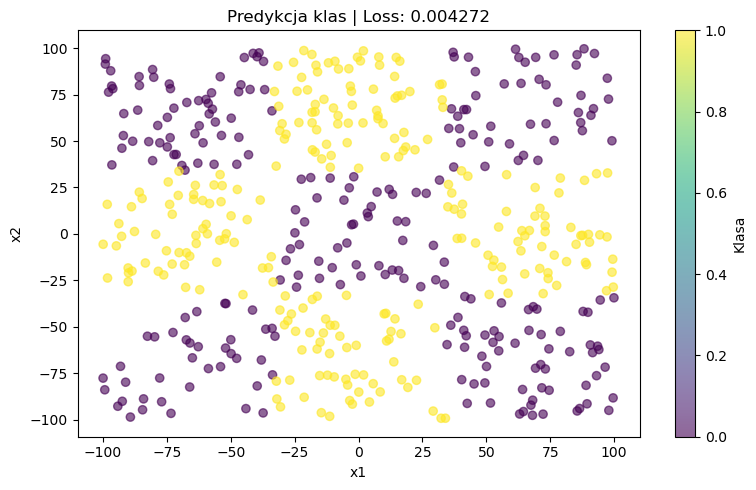

Wagi:
[array([[-4.89215211, -0.76012586, -1.18878121,  6.74379651, -9.10657888,
         6.36848887,  9.06313061,  0.60197677, -3.60489036, -0.55072996,
        -9.0947642 , -0.63544083, -0.24016673, -7.09546877, -2.27006682,
         0.21995605],
       [ 3.38556872,  0.29336986, 16.43666651, -9.06594006, -4.78262712,
         5.44397232, -0.50000931,  0.6904772 , -6.0137797 , -0.35979312,
         7.05756221, -0.53793763,  4.806222  , -3.93267553,  5.8139582 ,
        -0.08426765]]), array([[ 1.5085591 ,  2.61298157,  1.76576891,  2.30074037,  1.92695848,
        -3.8828667 , -0.25952746,  0.08149288],
       [-0.15537497, -0.13744853,  0.47609795, -0.83168905, -0.19516706,
         0.92437837, -0.78668283, -0.2260538 ],
       [ 2.73620514, -0.85306283,  3.62448632, -3.73462299,  7.82572026,
        -5.56152979, -2.93346762, -0.11900692],
       [-5.28488507,  1.60832736, -6.18295287,  1.32276134, -0.66129946,
        -4.8053568 , -1.25807092,  0.05974549],
       [-4.26395343, -4.8

In [108]:
model_xor3.train(x_train, y_train, epochs=100000, lr=0.01, batch_size=16, update_method="Momentum", verbose = True, record_loss_every = 100, print_every = 10000)

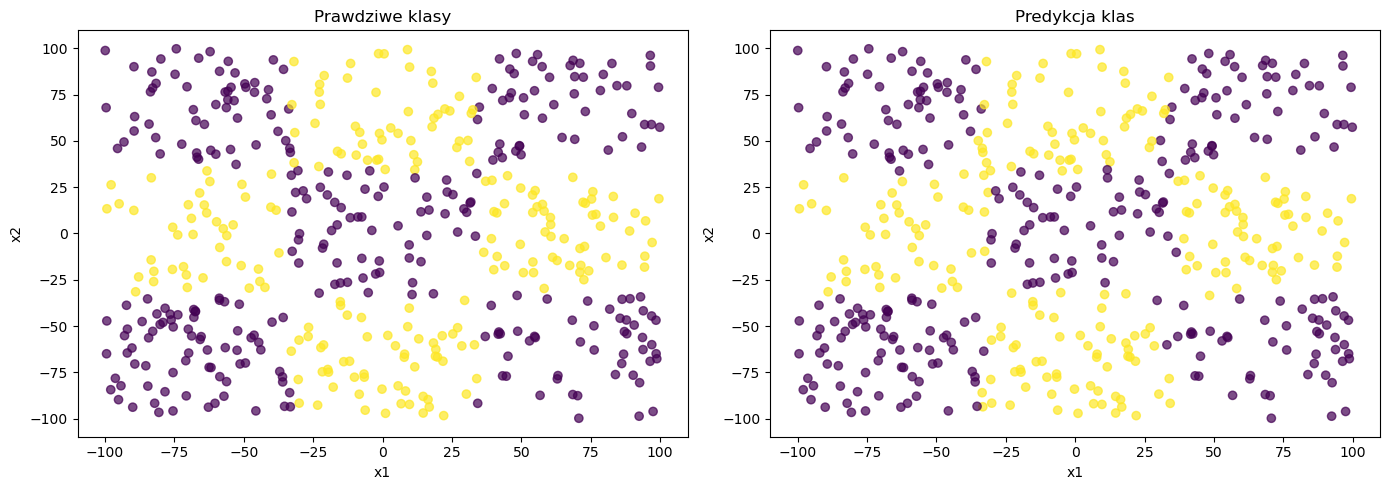

F-measure (macro): 0.9487
Accuracy:          0.9500


In [109]:
model_xor3.test_evaluation_classification(x_test, y_test)

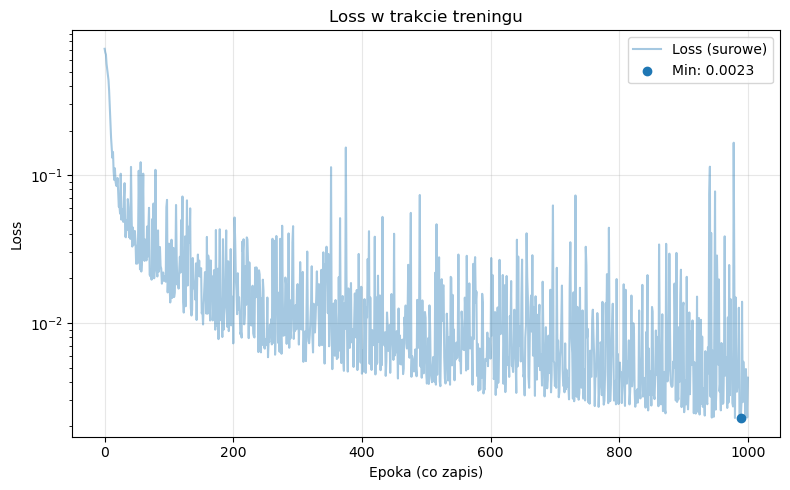

In [110]:
model_xor3.plot_loss()

In [85]:
# rings3-regular
x_train, x_test, y_train, y_test = load_data('rings3-regular')
model_rings3 = MLP(
    layer_num    = [2, 16, 8, 3],
    act_func     = relu,
    grad_act_func= grad_relu,
    use_softmax  = True
)

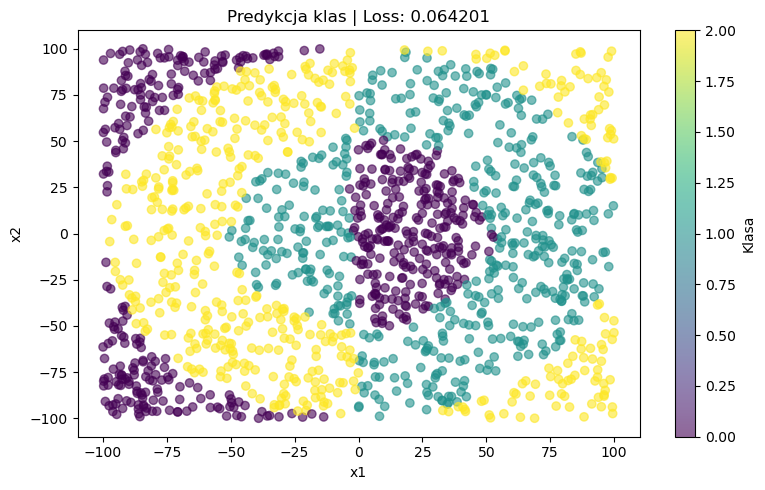

Wagi:
[array([[-10.30958336,  16.108004  ,  -0.20587853,   7.95329247,
         -0.30416346,   0.29539479,  -6.46838175,  -0.39262185,
        -11.04828974,  -6.10995501,   4.74326447,   3.44167114,
         -4.74225008,  16.90603064,  -0.55499428,   2.53654491],
       [  6.16214637,   0.68529149,  -0.03998256,   2.80882956,
         -0.51889447,  -0.39630103,  -6.60533163,   0.58980634,
        -15.33612959,  11.14013217,  -2.50091274,  -0.4641797 ,
          2.43934076,  -4.37358752,  -0.22985421,  15.25352673]]), array([[ 1.57810641e-01,  1.53961250e+00, -6.21197423e-01,
         8.75897939e-01, -8.83382516e+00, -1.47636766e+00,
        -1.78310618e+00,  1.35901777e+00],
       [-7.42070611e-01,  3.00857330e+00, -8.05824012e-02,
         4.27892187e-01, -7.41127642e+00,  1.04994664e+00,
         1.03373198e-01, -3.50028817e-01],
       [-5.24930764e-01, -7.69635765e-01, -7.63926357e-01,
         3.37560329e-01, -6.52103463e-01,  7.43512953e-01,
         2.02735315e-03,  1.71791638e

In [86]:
model_rings3.train(x_train, y_train, epochs=100000, lr=0.01, batch_size=16, update_method="Momentum")

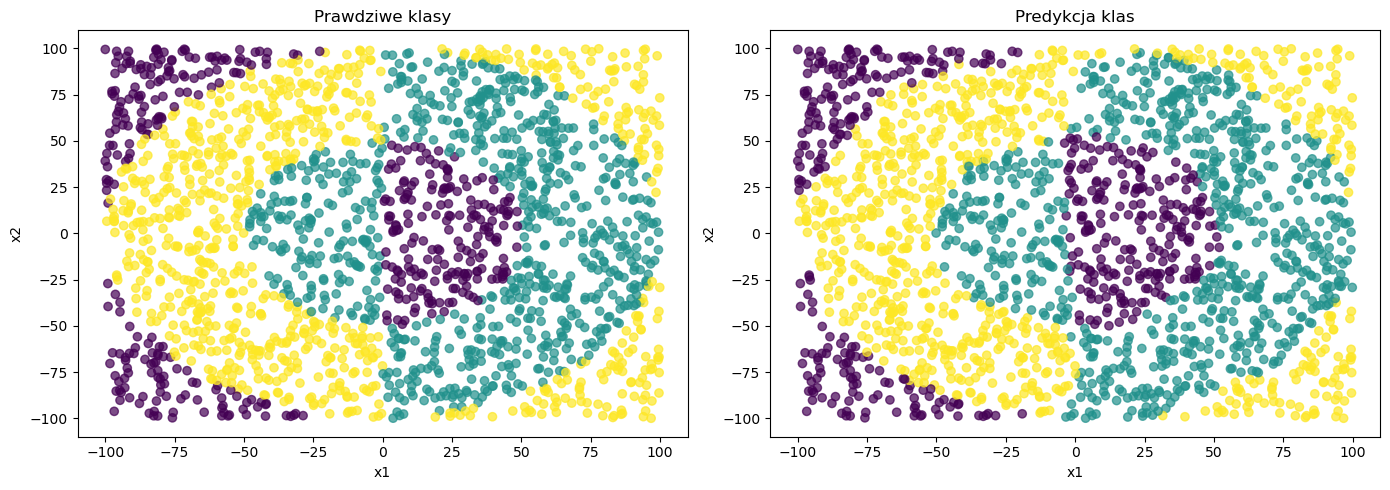

F-measure (macro): 0.9435
Accuracy:          0.9460


In [88]:
model_rings3.test_evaluation_classification(x_test, y_test)

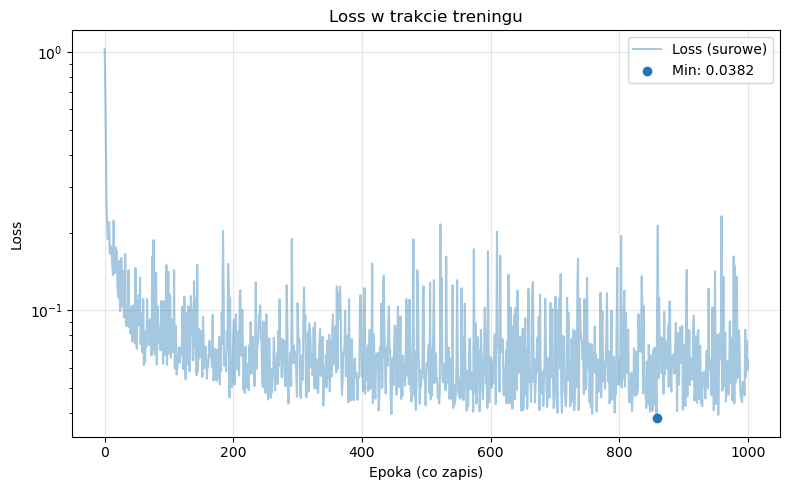

In [89]:
model_rings3.plot_loss()